# Figure 1

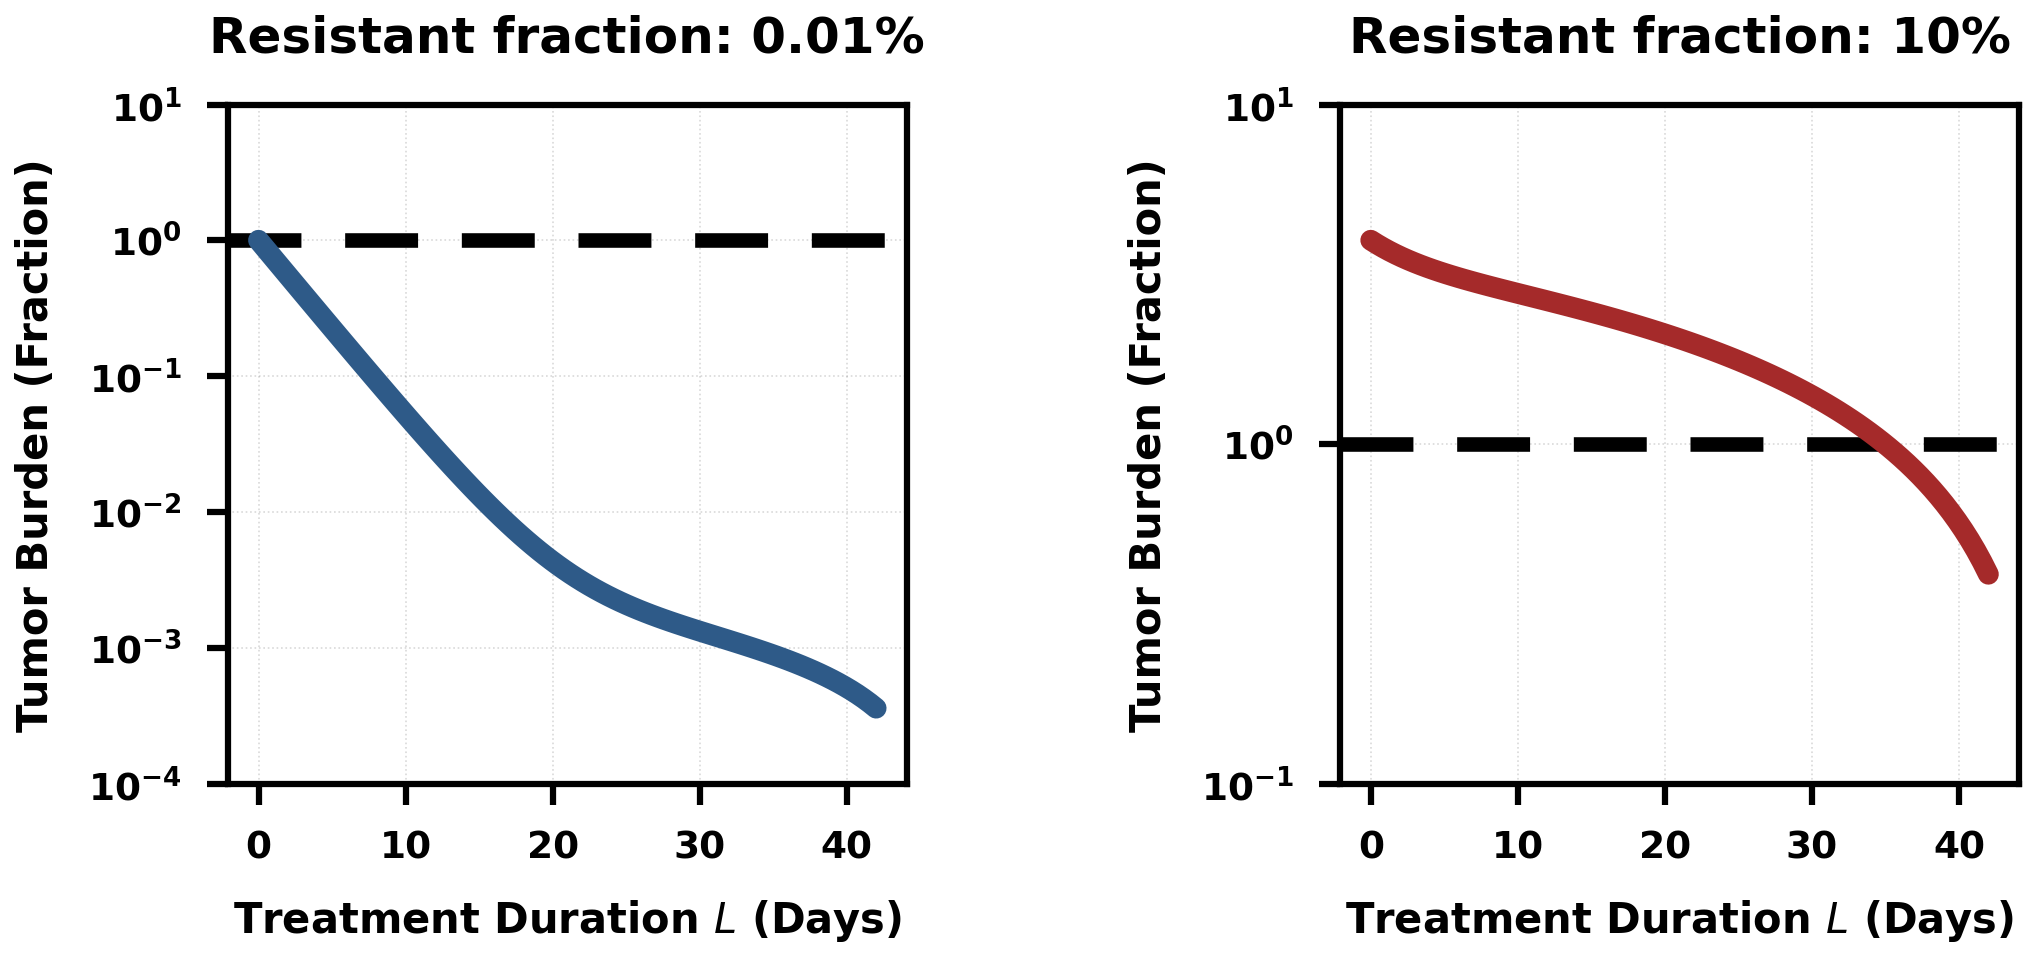

In [92]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

def get_final_burden_relative(R0, S0, L, total_days):
    p_s, lam, alpha = 0.03, np.log(2), 0.3
    initial_burden = R0 + S0

    def odes(t, y, Tx_val):
        R, S = y
        total = R + S
        if total <= 1e-15: return [0, 0]
        frac = R / total
        dRdt = frac * p_s * lam * R
        dSdt = (1 - frac * p_s) * lam * R - alpha * Tx_val * S
        return [dRdt, dSdt]

    y_curr = [R0, S0]
    if L > 0:
        sol1 = solve_ivp(odes, (0, L), y_curr, args=(1.0,), method='RK45', rtol=1e-10)
        y_curr = sol1.y[:, -1]
    if L < total_days:
        sol2 = solve_ivp(odes, (L, total_days), y_curr, args=(0.0,), method='RK45', rtol=1e-10)
        y_curr = sol2.y[:, -1]

    # CHANGED: Return as fraction (normalized to 1.0) instead of percentage
    return (y_curr[0] + y_curr[1]) / initial_burden

# --- ADJUSTABLE PARAMETERS ---
CYCLE_LENGTH = 42
TOTAL_INIT = 100
rf_low = 0.0001   # Will show as 0.01%
rf_high = 0.1     # Will show as 10%

L_range = np.linspace(0, CYCLE_LENGTH, 100)

# --- RUN SIMULATIONS ---
data_low = [get_final_burden_relative(rf_low*TOTAL_INIT, (1-rf_low)*TOTAL_INIT, l, CYCLE_LENGTH) for l in L_range]
data_high = [get_final_burden_relative(rf_high*TOTAL_INIT, (1-rf_high)*TOTAL_INIT, l, CYCLE_LENGTH) for l in L_range]

# --- PLOTTING ---
plt.rcParams['font.family'] = 'sans-serif'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

LINE_WIDTH = 10.0
BASELINE_WIDTH = 7.0 
LABEL_FONT = 20
TITLE_FONT = 24
TICK_FONT = 18  

def style_axis(ax, data, title_text):
    ax.set_title(title_text, fontsize=TITLE_FONT, fontweight='bold', pad=25)
    ax.set_xlabel('Treatment Duration $L$ (Days)', fontsize=LABEL_FONT, fontweight='bold', labelpad=15)
    # CHANGED: Label updated to Fraction
    ax.set_ylabel('Tumor Burden (Fraction)', fontsize=LABEL_FONT, fontweight='bold', labelpad=15)
    
    # --- DYNAMIC LOG SCALE FIXES ---
    ax.set_yscale('log')
    
    # CHANGED: Baseline is now 1.0 (10^0)
    all_vals = np.append(data, 1.0)
    y_min = 10**np.floor(np.log10(np.min(all_vals)))
    y_max = 10**np.ceil(np.log10(np.max(all_vals)))
    ax.set_ylim(y_min, y_max)
    
    # Set locator to show every power of 10
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    
    # Custom formatter for the 10^x look with Bold math
    class BoldLogFormatter(LogFormatterSciNotation):
        def __call__(self, x, pos=None):
            if x == 0: return '0'
            exponent = int(np.round(np.log10(x)))
            return r'$\mathbf{10^{%d}}$' % exponent

    ax.yaxis.set_major_formatter(BoldLogFormatter())
    
    # Ultra-visible ticks
    ax.tick_params(axis='both', which='major', labelsize=TICK_FONT, 
                   length=10, width=3, pad=12, direction='out', color='black')
    
    ax.tick_params(axis='y', which='minor', left=False)
    
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    
    # CHANGED: Baseline at 1.0 (equivalent to 10^0 on the log scale)
    ax.axhline(1.0, color='black', linestyle=(0, (5, 3)), linewidth=BASELINE_WIDTH, 
               alpha=1.0, zorder=2)
    
    ax.grid(True, ls=':', alpha=0.3, color='gray', zorder=1)
    ax.set_box_aspect(1)
    
    for spine in ax.spines.values():
        spine.set_linewidth(3.0)
        spine.set_color('black')

# Plot 1: Low Resistance
ax1.plot(L_range, data_low, color='#2E5A88', lw=LINE_WIDTH, solid_capstyle='round', zorder=3)
style_axis(ax1, data_low, f'Resistant fraction: {rf_low*100:.2g}%')

# Plot 2: High Resistance
ax2.plot(L_range, data_high, color='#A52A2A', lw=LINE_WIDTH, solid_capstyle='round', zorder=3)
style_axis(ax2, data_high, f'Resistant fraction: {rf_high*100:.2g}%')

plt.tight_layout(pad=6.0)
plt.show()

# Figure 2

Precomputing dynamics...
Solving Bellman Equation...


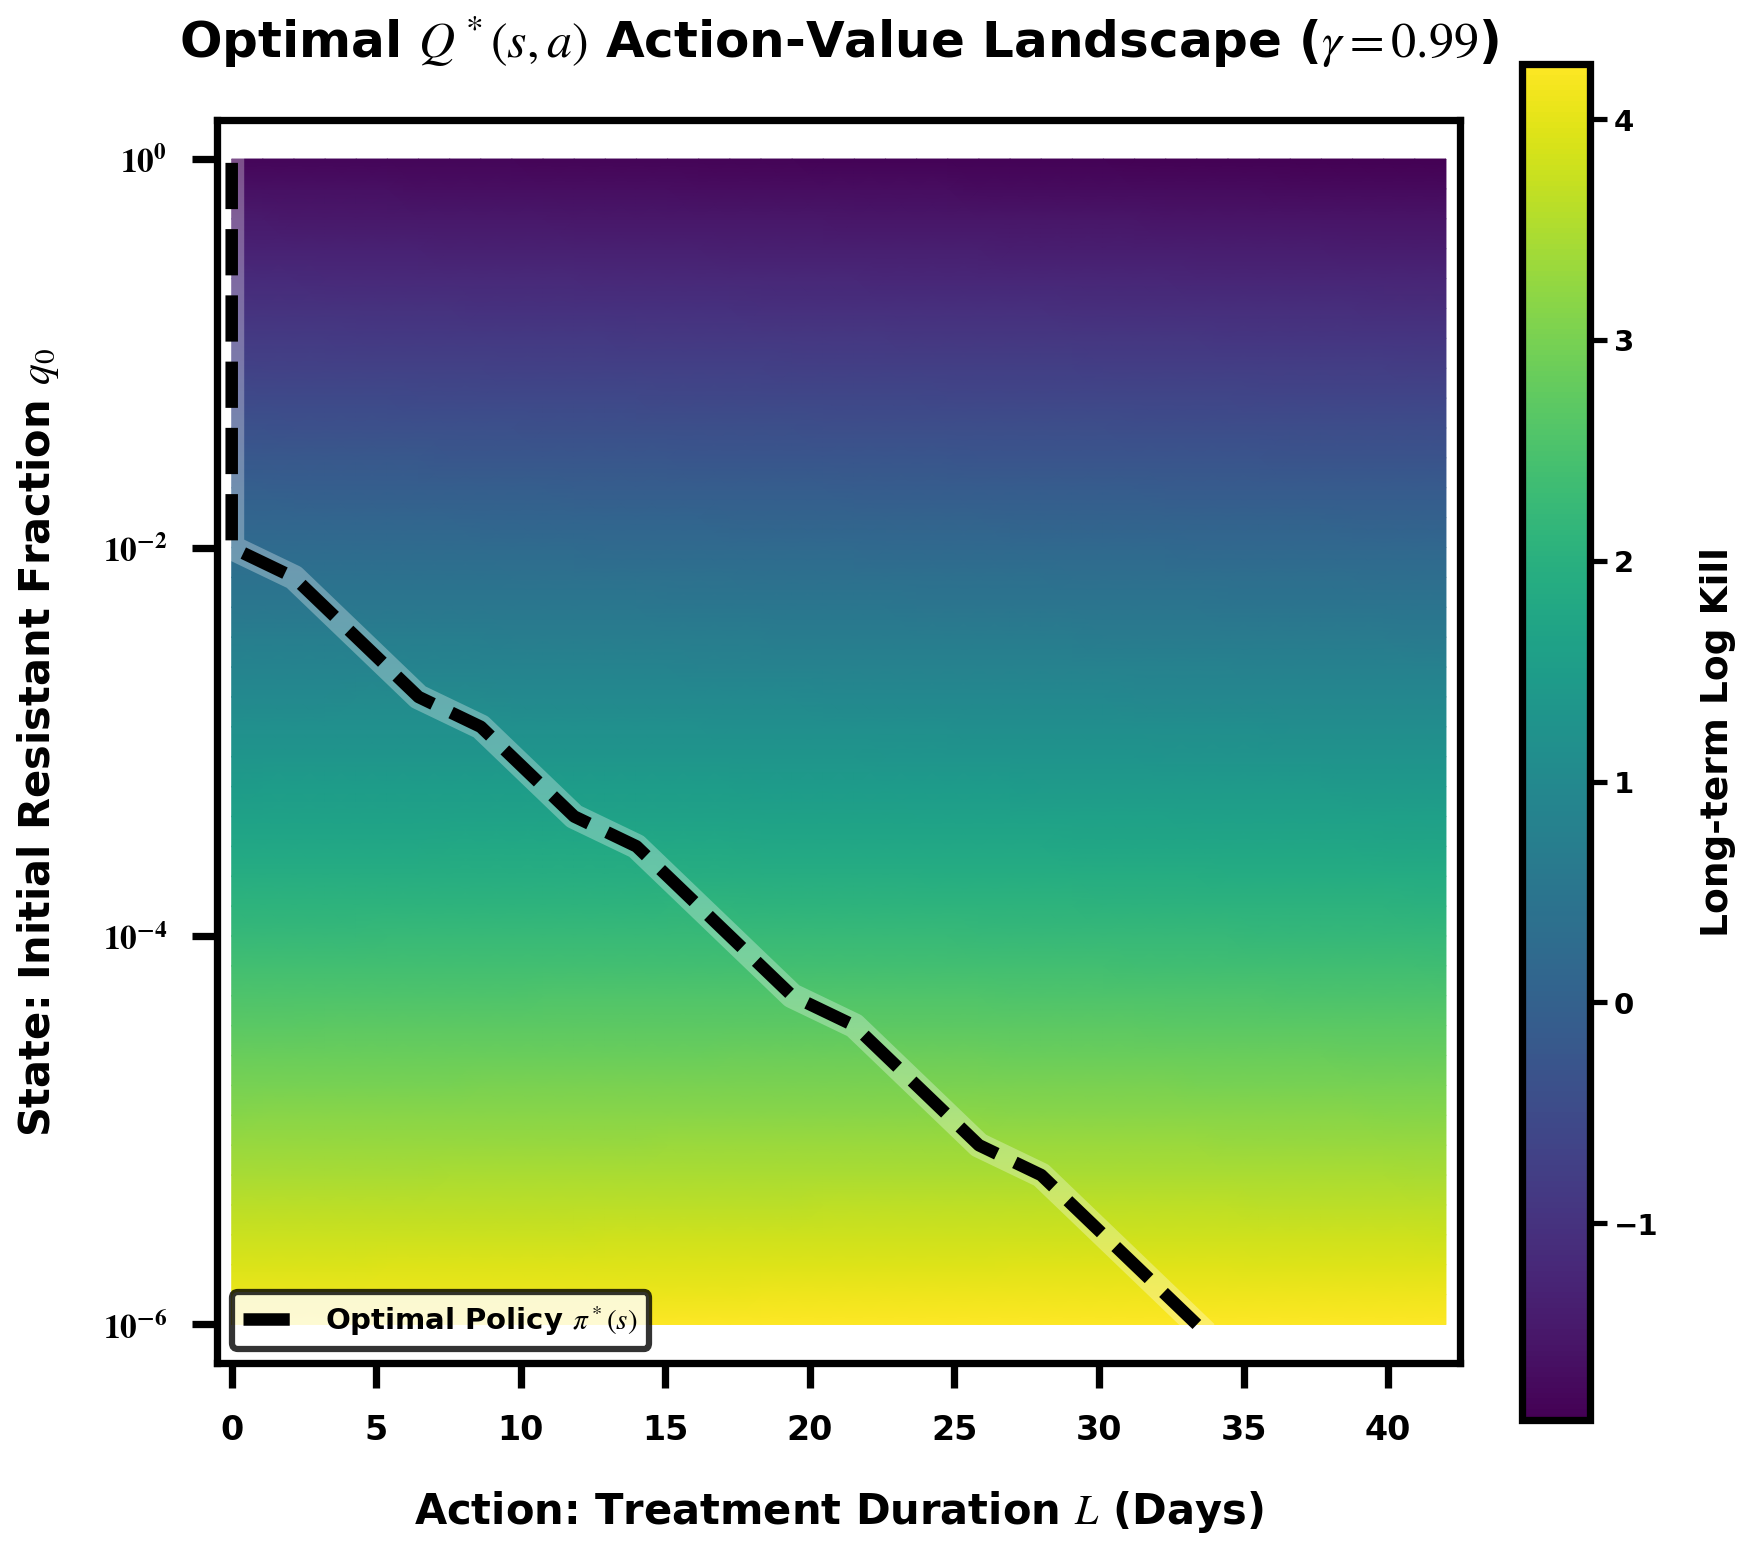

In [180]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.interpolate import interp1d

# --- 1. MODEL & ENVIRONMENT DYNAMICS ---
def simulate_cycle(q_start, L, total_days=42):
    p_s, lam, alpha = 0.03, np.log(2), 0.3
    V_init = 100
    R0 = q_start * V_init
    S0 = V_init - R0

    def odes(t, y, Tx_val):
        R, S = y
        total = R + S
        if total <= 1e-15: return [0, 0]
        frac = R / total
        dRdt = frac * p_s * lam * R
        dSdt = (1 - frac * p_s) * lam * R - alpha * Tx_val * S
        return [dRdt, dSdt]

    sol1 = solve_ivp(odes, (0, L), [R0, S0], args=(1.0,), method='RK45', rtol=1e-9)
    y1 = sol1.y[:, -1]
    sol2 = solve_ivp(odes, (L, total_days), y1, args=(0.0,), method='RK45', rtol=1e-9)
    y_final = sol2.y[:, -1]

    V_final = np.sum(y_final)
    q_final = y_final[0] / V_final if V_final > 1e-12 else 1.0
    reward = -np.log10(V_final / V_init)
    return q_final, reward

# --- 2. DISCRETE SPACE SETUP ---
n_states, n_actions = 40, 40
gamma = 0.99

q_grid = np.logspace(-6, 0, n_states)
L_grid = np.linspace(0, 42, n_actions)

R_matrix = np.zeros((n_states, n_actions))
S_prime_matrix = np.zeros((n_states, n_actions))

print("Precomputing dynamics...")
for i, q in enumerate(q_grid):
    for j, L in enumerate(L_grid):
        q_next, rew = simulate_cycle(q, L)
        R_matrix[i, j] = rew
        S_prime_matrix[i, j] = q_next

# --- 3. VALUE ITERATION ---
V_star = np.zeros(n_states)
Q_star = np.zeros((n_states, n_actions))

print("Solving Bellman Equation...")
for iteration in range(100):
    V_prev = V_star.copy()
    V_interp = interp1d(np.log10(q_grid), V_prev, kind='linear', fill_value="extrapolate")
    for i in range(n_states):
        for j in range(n_actions):
            Q_star[i, j] = R_matrix[i, j] + gamma * V_interp(np.log10(S_prime_matrix[i, j]))
    V_star = np.max(Q_star, axis=1)
    if np.max(np.abs(V_star - V_prev)) < 1e-4: break

# --- 4. PUBLICATION QUALITY SQUARE HEATMAP (VIRIDIS) ---
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.weight': 'bold',
    'axes.labelweight': 'bold', 'figure.dpi': 150,
    'axes.linewidth': 3.5 
})

fig, ax = plt.subplots(figsize=(12, 12))

X, Y = np.meshgrid(L_grid, np.log10(q_grid))

# Even spacing: Linear mapping across the data range using Viridis
mesh = ax.pcolormesh(X, Y, Q_star, cmap='viridis', shading='gouraud')

# --- OPTIMAL POLICY OVERLAY ---
optimal_L = L_grid[np.argmax(Q_star, axis=1)]

# Subtle white halo to ensure the black line is visible against dark viridis colors
ax.plot(optimal_L, np.log10(q_grid), color='white', lw=12, ls='-', alpha=0.3)
# Main Black Policy line
ax.plot(optimal_L, np.log10(q_grid), color='black', lw=6, ls='--', label=r'Optimal Policy $\pi^*(s)$')

# --- STYLING ---
ax.set_title(r'Optimal $Q^*(s, a)$ Action-Value Landscape ($\gamma = %.2f$)' % gamma, 
             fontsize=24, pad=30, fontweight='bold')
ax.set_xlabel('Action: Treatment Duration $L$ (Days)', fontsize=20, labelpad=20)
ax.set_ylabel('State: Initial Resistant Fraction $q_0$', fontsize=20, labelpad=20)

y_ticks = [-6, -4, -2, 0]
y_labs = [r'$\mathbf{10^{-6}}$', r'$\mathbf{10^{-4}}$', r'$\mathbf{10^{-2}}$', r'$\mathbf{10^{0}}$']
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labs)

# High-Presence Ticks
ax.tick_params(axis='both', which='major', labelsize=16, length=12, width=3.5, pad=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Colorbar with even spacing
cbar = fig.colorbar(mesh, ax=ax, pad=0.04, shrink=0.8)
cbar.set_label('Long-term Log Kill', fontsize=18, fontweight='bold', labelpad=20)
cbar.ax.tick_params(labelsize=14, width=2.5, length=8)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

# --- LEGEND ---
leg = ax.legend(loc='lower left', fontsize=14, frameon=True, facecolor='white', edgecolor='black')
leg.get_frame().set_linewidth(3.0)

# --- THE SQUARE FIX ---
ax.set_box_aspect(1) 

# Limits for clean viewing
ax.set_xlim(-0.5, 42.5)
ax.set_ylim(-6.2, 0.2)

plt.tight_layout()
plt.show()

# Figure 3

Precomputing dynamics...
Solving Bellman Equation...


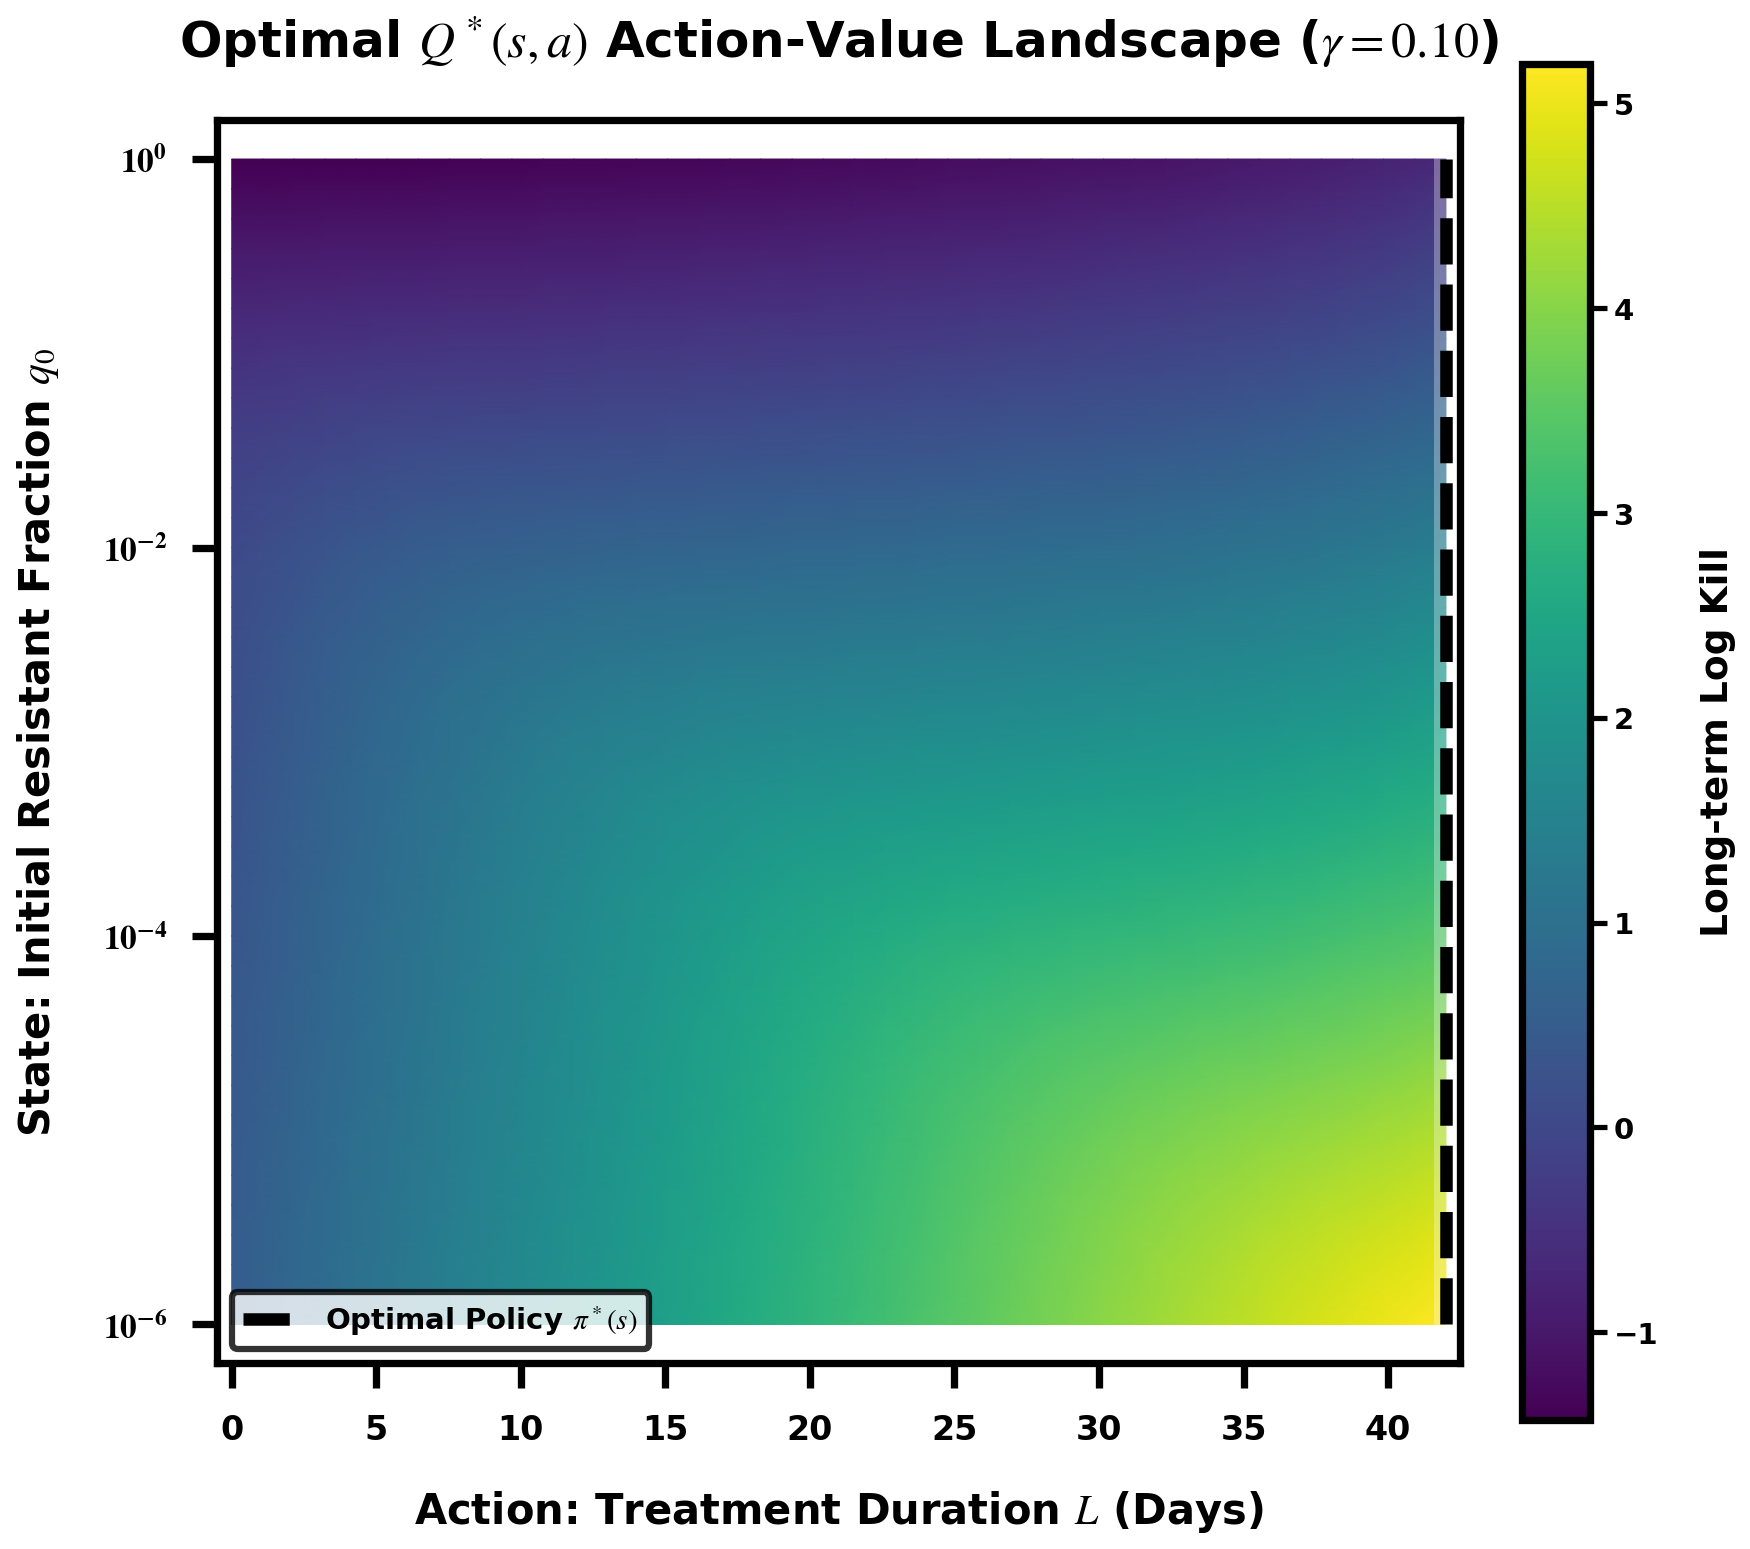

In [181]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.interpolate import interp1d

# --- 1. MODEL & ENVIRONMENT DYNAMICS ---
def simulate_cycle(q_start, L, total_days=42):
    p_s, lam, alpha = 0.03, np.log(2), 0.3
    V_init = 100
    R0 = q_start * V_init
    S0 = V_init - R0

    def odes(t, y, Tx_val):
        R, S = y
        total = R + S
        if total <= 1e-15: return [0, 0]
        frac = R / total
        dRdt = frac * p_s * lam * R
        dSdt = (1 - frac * p_s) * lam * R - alpha * Tx_val * S
        return [dRdt, dSdt]

    sol1 = solve_ivp(odes, (0, L), [R0, S0], args=(1.0,), method='RK45', rtol=1e-9)
    y1 = sol1.y[:, -1]
    sol2 = solve_ivp(odes, (L, total_days), y1, args=(0.0,), method='RK45', rtol=1e-9)
    y_final = sol2.y[:, -1]

    V_final = np.sum(y_final)
    q_final = y_final[0] / V_final if V_final > 1e-12 else 1.0
    reward = -np.log10(V_final / V_init)
    return q_final, reward

# --- 2. DISCRETE SPACE SETUP ---
n_states, n_actions = 40, 40
gamma = 0.1

q_grid = np.logspace(-6, 0, n_states)
L_grid = np.linspace(0, 42, n_actions)

R_matrix = np.zeros((n_states, n_actions))
S_prime_matrix = np.zeros((n_states, n_actions))

print("Precomputing dynamics...")
for i, q in enumerate(q_grid):
    for j, L in enumerate(L_grid):
        q_next, rew = simulate_cycle(q, L)
        R_matrix[i, j] = rew
        S_prime_matrix[i, j] = q_next

# --- 3. VALUE ITERATION ---
V_star = np.zeros(n_states)
Q_star = np.zeros((n_states, n_actions))

print("Solving Bellman Equation...")
for iteration in range(100):
    V_prev = V_star.copy()
    V_interp = interp1d(np.log10(q_grid), V_prev, kind='linear', fill_value="extrapolate")
    for i in range(n_states):
        for j in range(n_actions):
            Q_star[i, j] = R_matrix[i, j] + gamma * V_interp(np.log10(S_prime_matrix[i, j]))
    V_star = np.max(Q_star, axis=1)
    if np.max(np.abs(V_star - V_prev)) < 1e-4: break

# --- 4. PUBLICATION QUALITY SQUARE HEATMAP (VIRIDIS) ---
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.weight': 'bold',
    'axes.labelweight': 'bold', 'figure.dpi': 150,
    'axes.linewidth': 3.5 
})

fig, ax = plt.subplots(figsize=(12, 12))

X, Y = np.meshgrid(L_grid, np.log10(q_grid))

# Even spacing: Linear mapping across the data range using Viridis
mesh = ax.pcolormesh(X, Y, Q_star, cmap='viridis', shading='gouraud')

# --- OPTIMAL POLICY OVERLAY ---
optimal_L = L_grid[np.argmax(Q_star, axis=1)]

# Subtle white halo to ensure the black line is visible against dark viridis colors
ax.plot(optimal_L, np.log10(q_grid), color='white', lw=12, ls='-', alpha=0.3)
# Main Black Policy line
ax.plot(optimal_L, np.log10(q_grid), color='black', lw=6, ls='--', label=r'Optimal Policy $\pi^*(s)$')

# --- STYLING ---
ax.set_title(r'Optimal $Q^*(s, a)$ Action-Value Landscape ($\gamma = %.2f$)' % gamma, 
             fontsize=24, pad=30, fontweight='bold')
ax.set_xlabel('Action: Treatment Duration $L$ (Days)', fontsize=20, labelpad=20)
ax.set_ylabel('State: Initial Resistant Fraction $q_0$', fontsize=20, labelpad=20)

y_ticks = [-6, -4, -2, 0]
y_labs = [r'$\mathbf{10^{-6}}$', r'$\mathbf{10^{-4}}$', r'$\mathbf{10^{-2}}$', r'$\mathbf{10^{0}}$']
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labs)

# High-Presence Ticks
ax.tick_params(axis='both', which='major', labelsize=16, length=12, width=3.5, pad=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Colorbar with even spacing
cbar = fig.colorbar(mesh, ax=ax, pad=0.04, shrink=0.8)
cbar.set_label('Long-term Log Kill', fontsize=18, fontweight='bold', labelpad=20)
cbar.ax.tick_params(labelsize=14, width=2.5, length=8)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

# --- LEGEND ---
leg = ax.legend(loc='lower left', fontsize=14, frameon=True, facecolor='white', edgecolor='black')
leg.get_frame().set_linewidth(3.0)

# --- THE SQUARE FIX ---
ax.set_box_aspect(1) 

# Limits for clean viewing
ax.set_xlim(-0.5, 42.5)
ax.set_ylim(-6.2, 0.2)

plt.tight_layout()
plt.show()

# Figure 4

Solving Reward Dynamics...
Converging Bellman Equation...


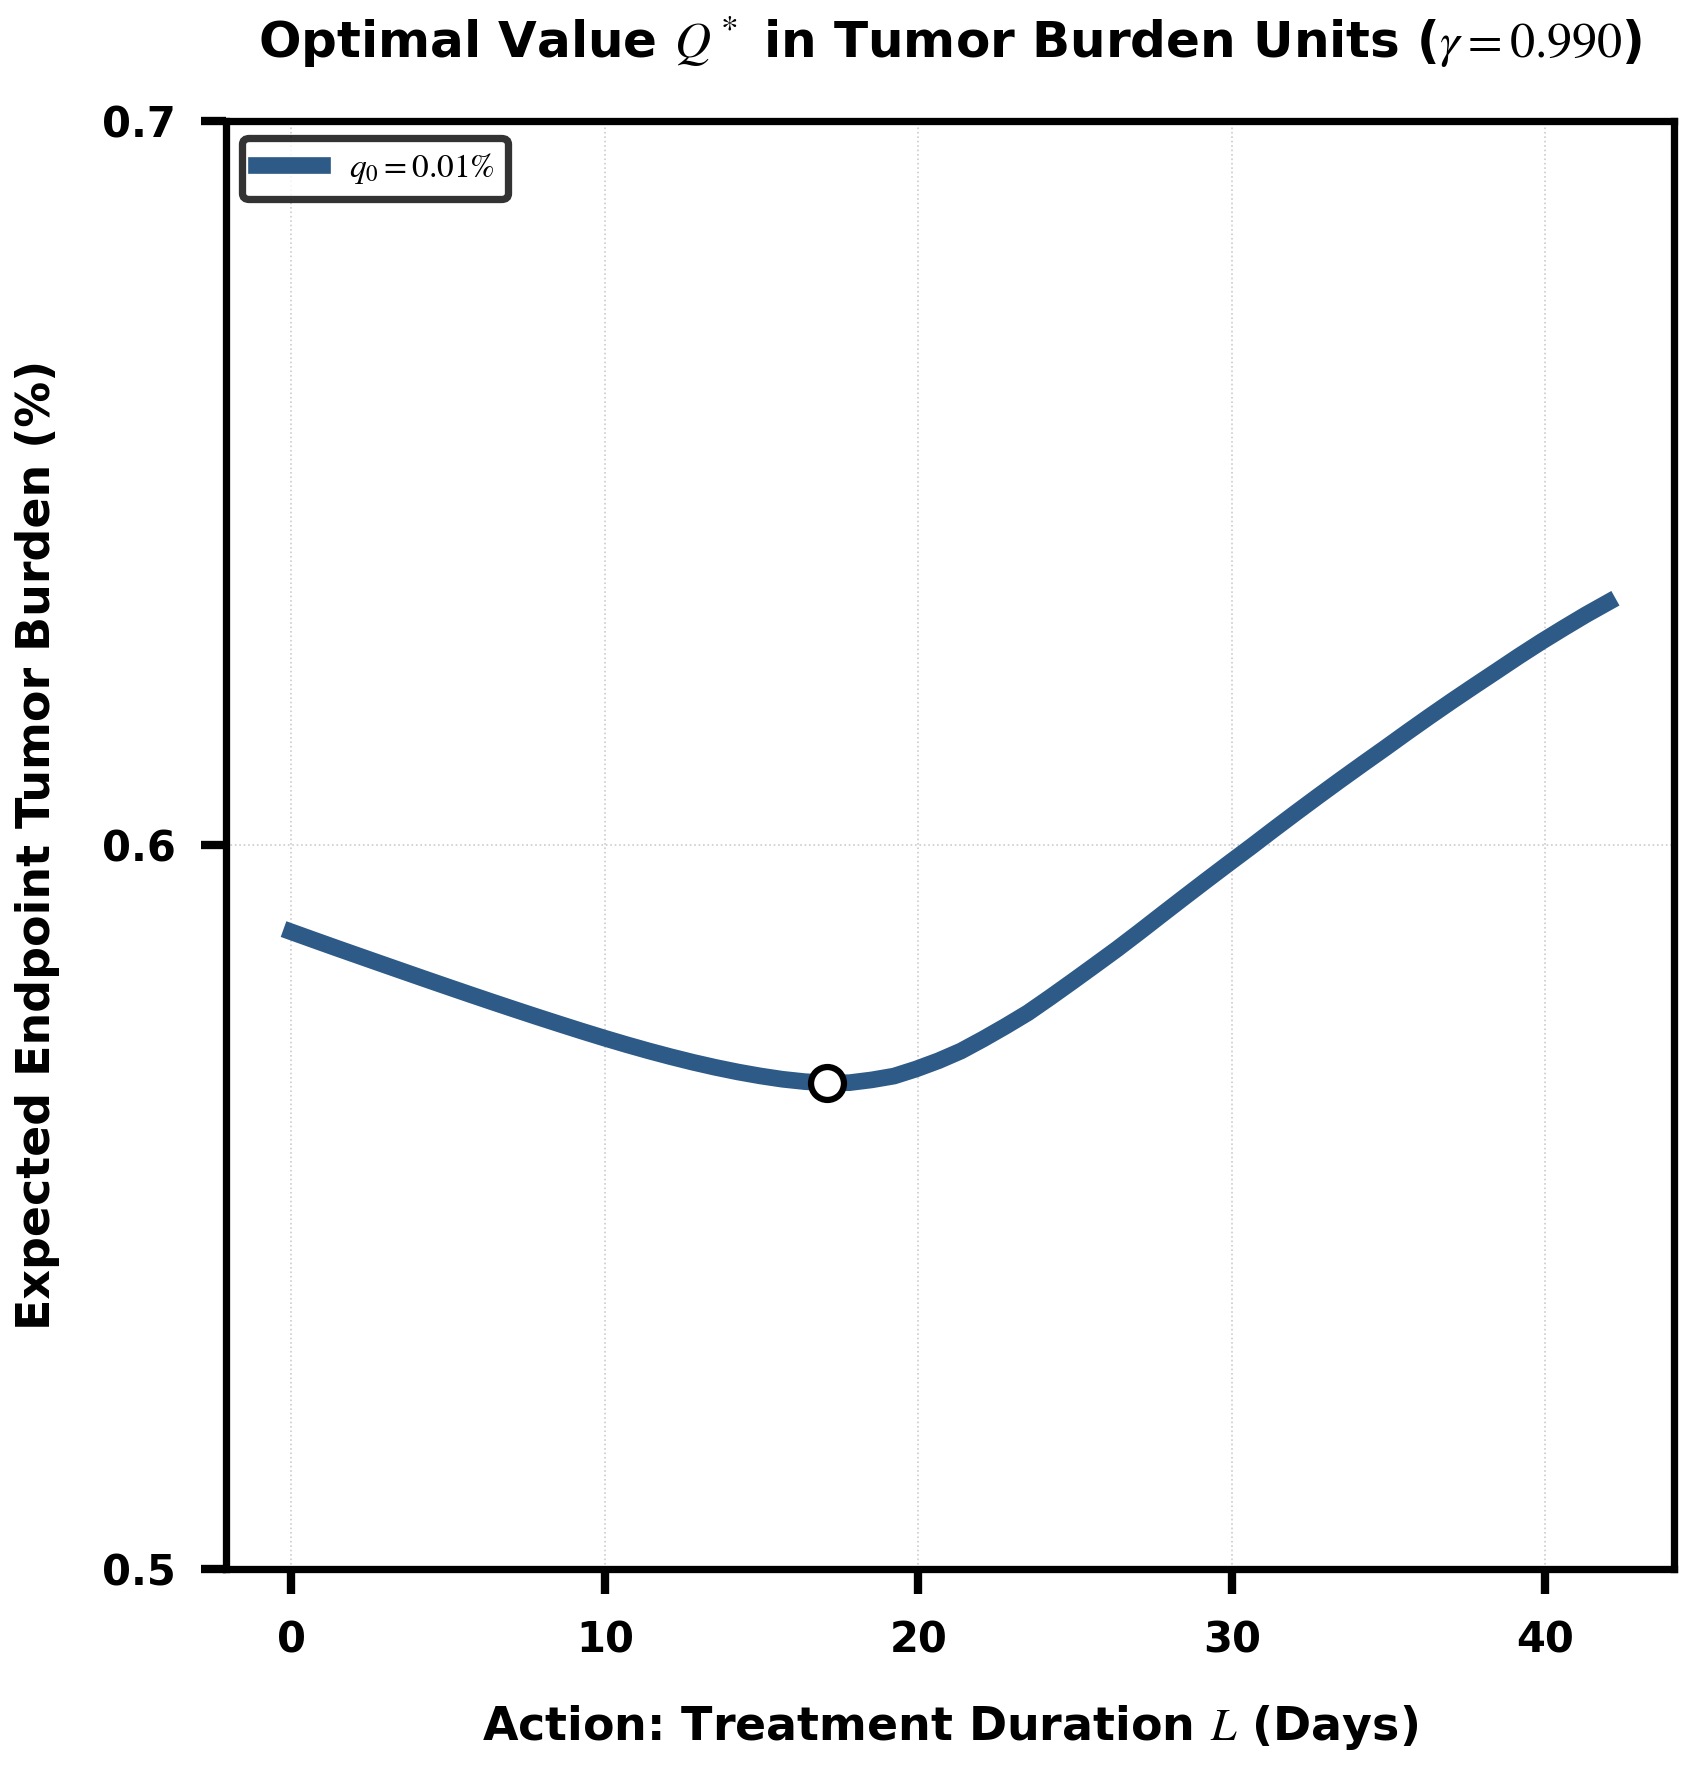

In [170]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.interpolate import interp1d

# --- 1. MODEL & ENVIRONMENT DYNAMICS ---
def simulate_cycle(q_start, L, total_days=42):
    p_s, lam, alpha = 0.03, np.log(2), 0.3
    V_init = 100
    R0 = q_start * V_init
    S0 = V_init - R0

    def odes(t, y, Tx_val):
        R, S = y
        total = R + S
        if total <= 1e-15: return [0, 0]
        frac = R / total
        dRdt = frac * p_s * lam * R
        dSdt = (1 - frac * p_s) * lam * R - alpha * Tx_val * S
        return [dRdt, dSdt]

    sol1 = solve_ivp(odes, (0, L), [R0, S0], args=(1.0,), method='RK45', rtol=1e-9)
    y1 = sol1.y[:, -1]
    sol2 = solve_ivp(odes, (L, total_days), y1, args=(0.0,), method='RK45', rtol=1e-9)
    y_final = sol2.y[:, -1]

    V_final = np.sum(y_final)
    q_final = y_final[0] / V_final if V_final > 1e-12 else 1.0
    reward = -np.log10(V_final / V_init)
    return q_final, reward

# --- 2. DISCRETE SPACE & VALUE ITERATION ---
n_states, n_actions = 40, 60
gamma_val = 0.990 
q_grid = np.logspace(-6, 0, n_states)
L_grid = np.linspace(0, 42, n_actions)

R_matrix = np.zeros((n_states, n_actions))
S_prime_matrix = np.zeros((n_states, n_actions))

print("Solving Reward Dynamics...")
for i, q in enumerate(q_grid):
    for j, L in enumerate(L_grid):
        q_next, rew = simulate_cycle(q, L)
        R_matrix[i, j], S_prime_matrix[i, j] = rew, q_next

V_star = np.zeros(n_states)
Q_star = np.zeros((n_states, n_actions))

print("Converging Bellman Equation...")
for iteration in range(100):
    V_prev = V_star.copy()
    V_interp = interp1d(np.log10(q_grid), V_prev, kind='linear', fill_value="extrapolate")
    for i in range(n_states):
        for j in range(n_actions):
            Q_star[i, j] = R_matrix[i, j] + gamma_val * V_interp(np.log10(S_prime_matrix[i, j]))
    V_star = np.max(Q_star, axis=1)
    if np.max(np.abs(V_star - V_prev)) < 1e-5: break

# --- 3. PLOTTING ---
LABEL_SIZE, TICK_SIZE, LINE_WIDTH = 22, 20, 8

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.weight': 'bold',
    'axes.labelweight': 'bold', 'figure.dpi': 150,
    'axes.linewidth': 3.5
})

# Adjusted figsize to better accommodate the square plot
fig, ax = plt.subplots(figsize=(12, 12))

# State to slice: 0.01%
target_qs = [1e-4]
colors = ['#2E5A88'] 

for q_val, color in zip(target_qs, colors):
    idx = np.argmin(np.abs(q_grid - q_val))
    q_slice_pct = 100 * (10 ** (-Q_star[idx, :]))
    
    ax.plot(L_grid, q_slice_pct, color=color, lw=LINE_WIDTH, 
            label=f'$q_0 = {q_val*100:.2g}\%$', zorder=3)
    
    # Optimal marker
    opt_idx = np.argmin(q_slice_pct)
    ax.scatter(L_grid[opt_idx], q_slice_pct[opt_idx], color='white', s=250, 
               edgecolor='black', lw=3, zorder=5)

# --- STYLING ---
ax.set_title(r'Optimal Value $Q^*$ in Tumor Burden Units ($\gamma = %.3f$)' % gamma_val, 
             fontsize=24, pad=30, fontweight='bold')
ax.set_xlabel('Action: Treatment Duration $L$ (Days)', fontsize=22, labelpad=20)
ax.set_ylabel('Expected Endpoint Tumor Burden (%)', fontsize=22, labelpad=20)

# Set the aspect ratio to be square
ax.set_box_aspect(1)

# --- Y-TICKS & LIMITS ---
y_ticks = [0.5, 0.6, 0.7]
ax.yaxis.set_major_locator(FixedLocator(y_ticks))
ax.yaxis.set_major_formatter(FixedFormatter([f'{val:.1f}' for val in y_ticks]))
ax.set_ylim(0.5, 0.7) 

ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE, length=12, width=4, pad=12)
ax.grid(True, ls=':', alpha=0.4, color='gray')

# Legend & Spines
leg = ax.legend(fontsize=16, frameon=True, facecolor='white', edgecolor='black', loc='upper left')
leg.get_frame().set_linewidth(3.5)

for spine in ax.spines.values():
    spine.set_linewidth(3.5)

plt.tight_layout()
plt.show()